# Welche Spielstatistiken erklären den Erfolg von PGA-Tour-Profis?

## 1. Einleitung

Golf kann man in mehrere Bereiche unterteilen, lange Schläge, Annäherungenschläge, kurze Schläge, Putten. Die PGA
Tour erfasst für jede Saison Durchschnittswerte zu diesen Bereichen. Nun kann man sich die Frage stellen: welche dieser
Statistiken hängt am stärksten mit Erfolg zusammen?

Erfolg messen wir auf folgende drei Arten: Scoring Average (Schlagdurchschnitt pro Runde), Preisgeld einer Saison und
Rang in der FedExCup-Wertung.

Wir haben folgende Vermutungen angestellt:
- Driving Distance und GIR sollten das Scoring Average verbessern
- Bei Preisgeld und Rang erwarte wir, dass Scrambling und Putts wichtiger werden, weil dort vorallem das
kurze Spiel unter zählt.


Wir verwenden folgende Methoden:

Eine lineare Regression beschreibt eine Zielgröße $y$ über einen Prädiktor $x$, mit
$y = a_0 + a_1 x + \varepsilon$. Gesucht sind die Werte für $a_0$ und $a_1$, die die Residuenquadratsumme

$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

minimieren. $R^2$ zeigt dann, wie viel von der Varianz in $y$ durch $x$ erklärt wird:

$$R^2 = 1 - \frac{RSS}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

Betrachtet haben wir hier in den 15 Regressionen nur einen Prädiktor gegen eine Zielgröße.

## 2. Daten einlesen & aufbereiten

Verwendet wird der Datensatz "PGA Tour Data (2010-2018)".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf

df = pd.read_csv("data/pgaTourData.csv")
df.shape

(2312, 18)

In [2]:
df.head()

,Player Name,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Points,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG,Money
0,Henrik Stenson,60.0,75.19,2018,291.5,73.51,29.93,60.67,69.617,868,NaN,5.0,-0.207,1.153,0.427,0.960,-0.027,"$2,680,487"
1,Ryan Armour,109.0,73.58,2018,283.5,68.22,29.31,60.13,70.758,"1,006",1.0,3.0,-0.058,0.337,-0.012,0.213,0.194,"$2,485,203"
2,Chez Reavie,93.0,72.24,2018,286.5,68.67,29.12,62.27,70.432,"1,020",NaN,3.0,0.192,0.674,0.183,0.437,-0.137,"$2,700,018"
3,Ryan Moore,78.0,71.94,2018,289.2,68.80,29.17,64.16,70.015,795,NaN,5.0,-0.271,0.941,0.406,0.532,0.273,"$1,986,608"
4,Brian Stuard,103.0,71.44,2018,278.9,67.12,29.11,59.23,71.038,421,NaN,3.0,0.164,0.062,-0.227,0.099,0.026,"$1,089,763"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312 entries, 0 to 2311
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Player Name         2312 non-null   str    
 1   Rounds              1678 non-null   float64
 2   Fairway Percentage  1678 non-null   float64
 3   Year                2312 non-null   int64  
 4   Avg Distance        1678 non-null   float64
 5   gir                 1678 non-null   float64
 6   Average Putts       1678 non-null   float64
 7   Average Scrambling  1678 non-null   float64
 8   Average Score       1678 non-null   float64
 9   Points              2296 non-null   str    
 10  Wins                293 non-null    float64
 11  Top 10              1458 non-null   float64
 12  Average SG Putts    1678 non-null   float64
 13  Average SG Total    1678 non-null   float64
 14  SG:OTT              1678 non-null   float64
 15  SG:APR              1678 non-null   float64
 16  SG:ARG           

In [4]:
df.describe()

,Rounds,Fairway Percentage,Year,Avg Distance,gir,Average Putts,Average Scrambling,Average Score,Wins,Top 10,Average SG Putts,Average SG Total,SG:OTT,SG:APR,SG:ARG
count,1678.000000,1678.000000,2312.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,293.000000,1458.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000
mean,78.711561,61.440560,2013.996107,290.807688,65.661675,29.163331,58.115638,70.921961,1.218430,2.781893,0.025641,0.148105,0.037759,0.065015,0.019974
std,14.274137,5.058845,2.581176,8.916631,2.745411,0.518468,3.384769,0.698305,0.573443,1.895094,0.343787,0.694923,0.379892,0.380952,0.223361
min,45.000000,43.020000,2010.000000,266.400000,53.540000,27.510000,44.010000,68.698000,1.000000,1.000000,-1.475000,-3.209000,-1.717000,-1.680000,-0.930000
25%,69.000000,57.942500,2012.000000,284.900000,63.830000,28.810000,55.900000,70.494250,1.000000,1.000000,-0.187000,-0.254750,-0.190250,-0.180750,-0.123000
50%,79.500000,61.430000,2014.000000,290.550000,65.790000,29.140000,58.275000,70.902000,1.000000,2.000000,0.040000,0.147000,0.056000,0.081000,0.022000
75%,89.000000,64.910000,2016.000000,296.400000,67.580000,29.520000,60.420000,71.342750,1.000000,4.000000,0.257000,0.568500,0.291500,0.314500,0.175000
max,120.000000,76.880000,2018.000000,319.700000,73.520000,31.000000,69.330000,74.400000,5.000000,14.000000,1.130000,2.406000,1.485000,1.533000,0.660000


Die Spalten im Rohdatensatz tragen andere Namen als die Variablen, um die es hier geht:

| Variable | Spalte im Rohdatensatz |
|---|---|
| Scoring Average | `Average Score` |
| Preisgeld | `Money` |
| Rang | abgeleitet aus `Points` |
| Driving Distance | `Avg Distance` |
| Driving Accuracy | `Fairway Percentage` |
| Greens in Regulation % | `gir` |
| Putts pro Runde | `Average Putts` |
| Scrambling % | `Average Scrambling` |

`Rounds`, `Wins`, `Top 10` und die `Strokes-Gained-Spalten` nutzen wir nicht.

Zwei Spalten `Points` und `Money` müssen nun noch nutzbar gemacht werden, indem wir die Trennzeichen und Dollarzeichen entfernen.

In [5]:
df["Points"] = pd.to_numeric(df["Points"].str.replace(",", "", regex=False), errors="coerce")
df["Money"] = pd.to_numeric(df["Money"].str.replace("[$,]", "", regex=True), errors="coerce")

Driving Distance, Fairway Percentage, GIR,Putts, Scrambling und Average Score fehlen bei genau denselben 634 Zeilen (über
isna().any(axis=1) haben wir das ermittelt). Vermutlich haben diese Spieler nicht genug Runden gespielt, um in die Statistik aufgenommen zu werden. Wir entfernen diese Zeilen.

In [6]:
spielstatistiken = ["Avg Distance", "Fairway Percentage", "gir", "Average Putts", "Average Scrambling", "Average Score"]
df = df.dropna(subset=spielstatistiken, how="all")
df.shape

(1678, 18)

Einen Rang gab es perse nicht im Rohdatensatz, deshalb erstellen wir eine Spalte `rank` aus `Points`.

In [7]:
df["rank"] = df.groupby("Year")["Points"].rank(ascending=False, method="min")

In [8]:
# hier benennen wir die Variablen für Verständnis und kürze um, es hat keinen methodischen Grund

spalten_umbenennen = {
    "Average Score": "scoring_avg",
    "Money": "money",
    "Avg Distance": "distance",
    "Fairway Percentage": "accuracy",
    "gir": "gir_pct",
    "Average Putts": "putts",
    "Average Scrambling": "scrambling",
}
df = df.rename(columns=spalten_umbenennen)

ziel_variablen = ["scoring_avg", "money", "rank"]
praediktoren = ["distance", "accuracy", "gir_pct", "putts", "scrambling"]


In [9]:
# Hier wird die Anzeige das Preisgeldes einfach in Millionen gewandelt, zur Lesbarkeit
def geld_achse(achse):
    achse.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

## 3. Explorative Datenanalyse

Hier haben wir uns, erneut für die Lesbarkeit, dazu entschieden, jedem Plot eine Zelle zu geben, damit wir nicht alle in eienm Raster darstellen müssen.

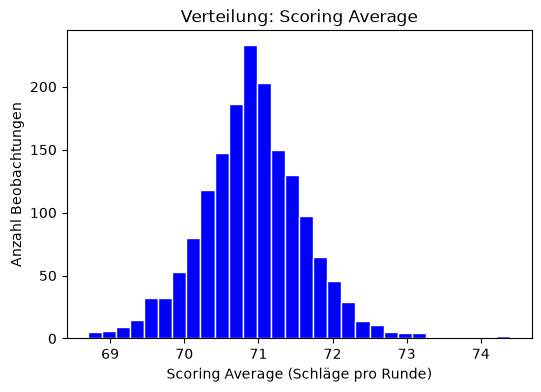

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(df["scoring_avg"].dropna(), bins=30, color="blue", edgecolor="white")
plt.xlabel("Scoring Average (Schläge pro Runde)")
plt.ylabel("Anzahl Beobachtungen")
plt.title("Verteilung: Scoring Average")
plt.show()

Die meisten Spieler-Saisons liegen zwischen etwa 70 und 72 Schlägen im Schnitt, die Verteilung ist recht
symmetrisch um knapp 71 Schläge.

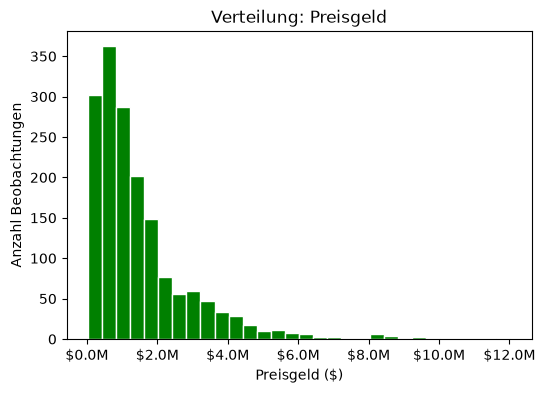

In [11]:
plt.figure(figsize=(6, 4))
plt.hist(df["money"].dropna(), bins=30, color="green", edgecolor="white")
ax = plt.gca()
geld_achse(ax.xaxis)
plt.xlabel("Preisgeld ($)")
plt.ylabel("Anzahl Beobachtungen")
plt.title("Verteilung: Preisgeld")
plt.show()

Der Median liegt bei rund 1,0 Mio. Dollar.
Der Mittelwert wegen einzelner Spieler
mit bis zu 12 Mio. Dollar aber bei knapp 1,5 Mio.

Da es 15 mögliche Streudiagramme gibt (3 Zielgrößen x 5 Prädiktoren), haben wir uns entschieden nur jeweils 2 mit der stärksten Korrelation zu zeigen.
Trotzdem werden alle 15 Regressionen in Abschnitt 4 vollständig berechnet,
hier geht es nur um eine Auswahl der gezeigten Diagramme.

In [12]:
ausgewaehlte_kombis = []
for ziel in ziel_variablen:
    korr = df[[ziel] + praediktoren].corr()[ziel].drop(ziel)
    top2 = korr.abs().sort_values(ascending=False).head(2).index.tolist()
    ausgewaehlte_kombis += [(ziel, p) for p in top2]

ausgewaehlte_kombis

[('scoring_avg', 'scrambling'),
 ('scoring_avg', 'gir_pct'),
 ('money', 'distance'),
 ('money', 'scrambling'),
 ('rank', 'scrambling'),
 ('rank', 'gir_pct')]

Scrambling taucht bei allen drei Zielgrößen unter den Top 2 auf, GIR bei zwei von drei.
Driving Accuracy und Putts pro Runde sind dagegen nirgends unter den stärksten zwei Prädiktoren.

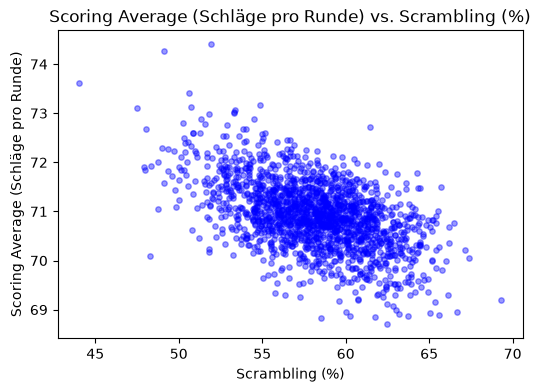

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["scoring_avg"], alpha=0.4, s=15, color="blue")
plt.xlabel("Scrambling (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average (Schläge pro Runde) vs. Scrambling (%)")
plt.show()

Mit besserem Scrambling sinkt der Scoring Average sichtbar.

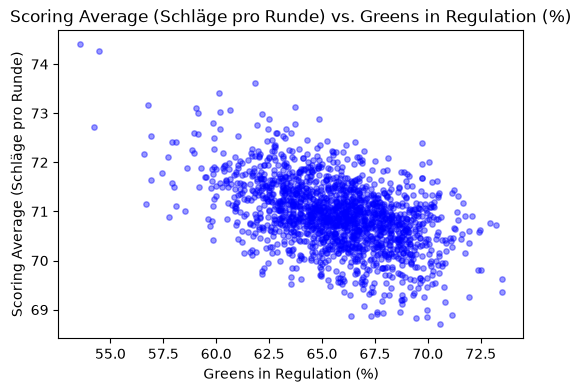

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["scoring_avg"], alpha=0.4, s=15, color="blue")
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average (Schläge pro Runde) vs. Greens in Regulation (%)")
plt.show()

Auch mehr getroffene Grüns senken den Scoring Average.

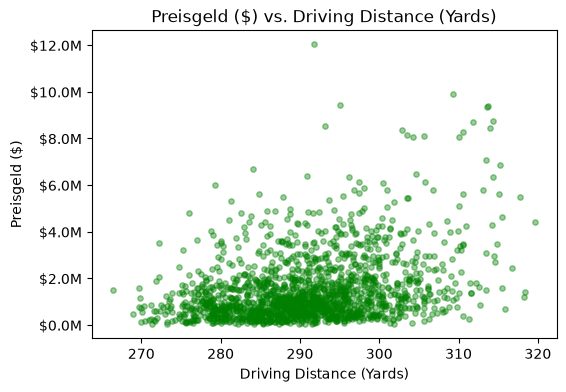

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(df["distance"], df["money"], alpha=0.4, s=15, color="green")
geld_achse(plt.gca().yaxis)
plt.xlabel("Driving Distance (Yards)")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld ($) vs. Driving Distance (Yards)")
plt.show()

Weiter schlagende Spieler verdienen im Schnitt mehr, wobei die Streuung bei jeder Distanz beträchtlich bleibt.

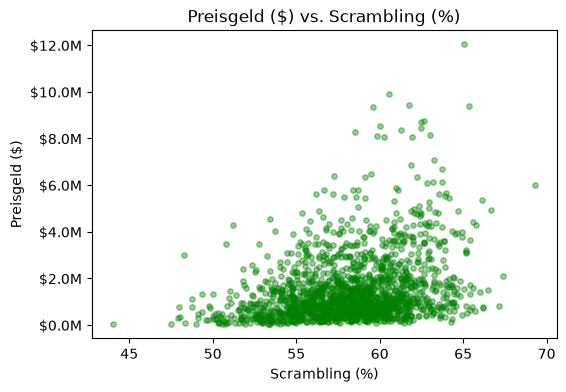

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["money"], alpha=0.4, s=15, color="green")
geld_achse(plt.gca().yaxis)
plt.xlabel("Scrambling (%)")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld ($) vs. Scrambling (%)")
plt.show()

Gutes Scrambling wirkt sich ähnlich stark aus wie eine hohe Driving Distance.

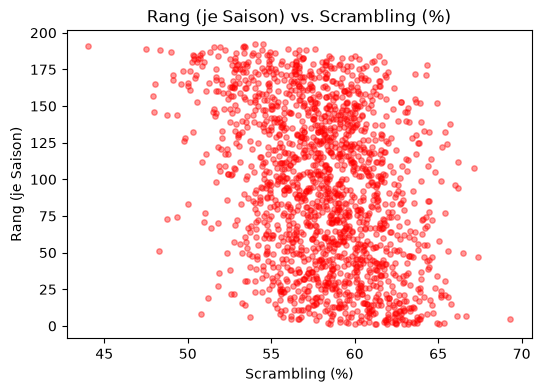

In [17]:
plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["rank"], alpha=0.4, s=15, color="red")
plt.xlabel("Scrambling (%)")
plt.ylabel("Rang (je Saison)")
plt.title("Rang (je Saison) vs. Scrambling (%)")
plt.show()

Spieler mit hohem Scrambling-Wert belegen tendenziell die vorderen (niedrigeren) Ränge.

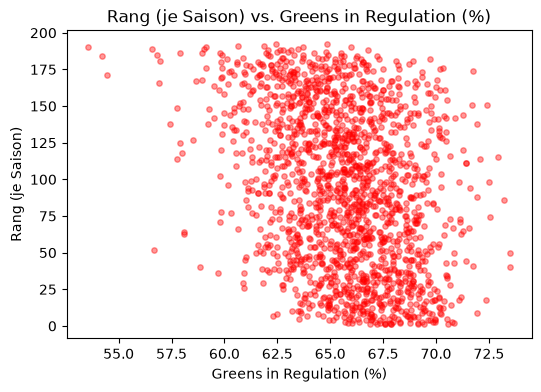

In [18]:
plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["rank"], alpha=0.4, s=15, color="red")
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Rang (je Saison)")
plt.title("Rang (je Saison) vs. Greens in Regulation (%)")
plt.show()

Ein hoher GIR-Prozentsatz hängt mit besseren Rängen zusammen, der Effekt fällt etwas schwächer aus als bei Scrambling.

Um die 8 Variablen auch untereinander zu vergleichen, nutzen wir eine Korrelationsmatrix.

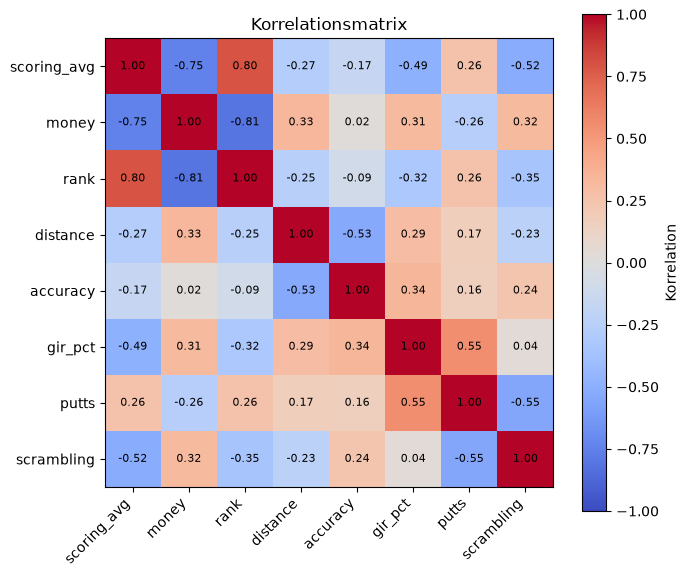

In [19]:
alle_variablen = ["scoring_avg", "money", "rank", "distance", "accuracy", "gir_pct", "putts", "scrambling"]
korr = df[alle_variablen].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(korr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(alle_variablen)))
ax.set_yticks(range(len(alle_variablen)))
ax.set_xticklabels(alle_variablen, rotation=45, ha="right")
ax.set_yticklabels(alle_variablen)
for i in range(len(alle_variablen)):
    for j in range(len(alle_variablen)):
        ax.text(j, i, f"{korr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Korrelation")
ax.set_title("Korrelationsmatrix")
fig.tight_layout()
plt.show()

Zum Schluss noch ein Blick über die Zeit: hat sich am Spiel zwischen 2010 und 2018 etwas verändert?

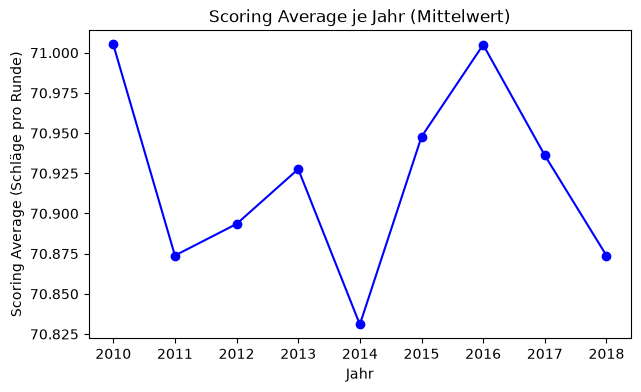

In [20]:
jahres_mittel = df.groupby("Year")[["scoring_avg", "distance"]].mean()

plt.figure(figsize=(7, 4))
plt.plot(jahres_mittel.index, jahres_mittel["scoring_avg"], marker="o", color="blue")
plt.xlabel("Jahr")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title("Scoring Average je Jahr (Mittelwert)")
plt.show()

Der durchschnittliche Scoring Average bleibt über die neun Saisons fast unverändert zwischen 70,8 und
71,0 Schlägen. Trotz technischer Fortschritte spielen die Spieler nicht stark erkennbar besser.

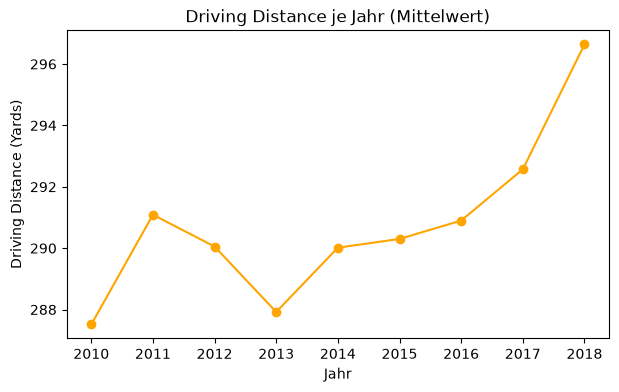

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(jahres_mittel.index, jahres_mittel["distance"], marker="o", color="orange")
plt.xlabel("Jahr")
plt.ylabel("Driving Distance (Yards)")
plt.title("Driving Distance je Jahr (Mittelwert)")
plt.show()

Die Schlaglänge dagegen steigt spürbar, von rund 287 Yards 2010 auf fast 297 Yards 2018. Dass der
Scoring Average trotzdem stabil bleibt, deutet darauf hin, dass sich die Plätze mit verändert und an die größeren Distanzen angepasst haben.

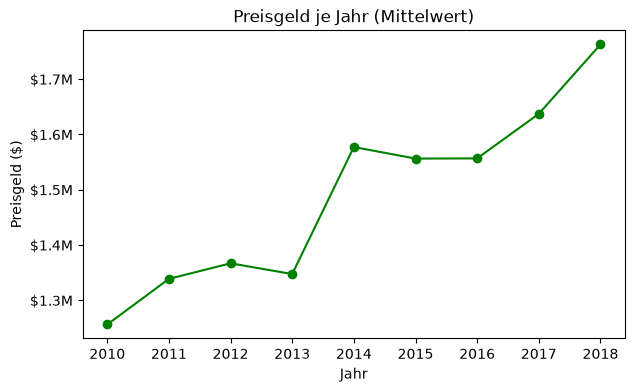

In [22]:
jahres_geld = df.groupby("Year")["money"].mean()

plt.figure(figsize=(7, 4))
plt.plot(jahres_geld.index, jahres_geld.values, marker="o", color="green")
ax = plt.gca()
geld_achse(ax.yaxis)
plt.xlabel("Jahr")
plt.ylabel("Preisgeld ($)")
plt.title("Preisgeld je Jahr (Mittelwert)")
plt.show()

Bis 2013 bewegt sich das durchschnittliche Preisgeld zwischen rund 1,25 und 1,37 Mio. Dollar. Ab 2014
springt es auf über 1,5 Mio. Dollar, bleibt 2015/2016 nahezu stabil und steigt 2017/2018 weiter an.
2018 werden im Schnitt rund 1,76 Mio. Dollar erreicht. Das passt zu den in dieser Zeit gestiegenen
Turnierpreisgeldern auf der Tour.

## 4. Regressionsanalyse

Der folgende Teil beschäftigt sich nun mit der eigentlichen Regressionsanalyse. Hier nutzen wir wieder die 3 Zielgrößen, mit den 5 Prädiktoren.
Wir haben uns für einfache Regressionen entschieden und nicht multiple Regressionen, mit mehreren Prädiktoren Gleihzeitig.

Die Funktion dient nur dem Zweck, dass man nicht 15x das gleiche Copy-pasted.

In [23]:
# schätzt ziel zu praediktor und gibt Intercept, Slope, Standardfehler, p-Wert, R2 und RMSE zurück
def regression(df, ziel, praed):
    daten = df[[ziel, praed]].dropna()
    modell = smf.ols(f"{ziel} ~ {praed}", data=daten).fit()
    rmse = np.sqrt(np.mean(modell.resid ** 2))

    return {
        "ziel": ziel,
        "praediktor": praed,
        "intercept": modell.params["Intercept"],
        "slope": modell.params[praed],
        "se_intercept": modell.bse["Intercept"],
        "se_slope": modell.bse[praed],
        "p_wert_slope": modell.pvalues[praed],
        "r_quadrat": modell.rsquared,
        "rmse": rmse,
    }

In [24]:
ergebnisse = []
for ziel in ziel_variablen:
    for praed in praediktoren:
        ergebnisse.append(regression(df, ziel, praed))

ergebnis_tabelle = pd.DataFrame(ergebnisse)

### Scoring Average

In [25]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "scoring_avg"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
4,scoring_avg,scrambling,77.133328,-0.106879,0.250928,0.004310,6.986709e-116,0.268383,0.597115
2,scoring_avg,gir_pct,79.022589,-0.123369,0.357068,0.005433,9.782440e-100,0.235254,0.610484
0,scoring_avg,distance,77.144651,-0.021398,0.535389,0.001840,4.100005e-30,0.074654,0.671534
3,scoring_avg,putts,60.589977,0.354280,0.925812,0.031741,5.911579e-28,0.069190,0.673514
1,scoring_avg,accuracy,72.363882,-0.023469,0.204837,0.003323,2.376708e-12,0.028906,0.687934


### Money

In [26]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "money"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
5,money,distance,-1.367070e+07,52132.404894,1.063551e+06,3655.790161,1.254466e-43,0.108435,1.331277e+06
9,money,scrambling,-6.202411e+06,132329.696170,5.621685e+05,9656.063884,1.367771e-40,0.100983,1.336829e+06
7,money,gir_pct,-9.104398e+06,161314.865905,7.846300e+05,11938.194811,1.452193e-39,0.098452,1.338709e+06
8,money,putts,2.192300e+07,-700680.395965,1.872992e+06,64213.574564,7.937244e-27,0.066478,1.362242e+06
6,money,accuracy,1.210464e+06,4527.640206,4.204027e+05,6818.488351,5.067665e-01,0.000264,1.409726e+06


### Rang

In [27]:
ergebnis_tabelle[ergebnis_tabelle["ziel"] == "rank"].sort_values("r_quadrat", ascending=False)

,ziel,praediktor,intercept,slope,se_intercept,se_slope,p_wert_slope,r_quadrat,rmse
14,rank,scrambling,417.697354,-5.577890,21.184513,0.363875,9.971170e-50,0.123222,50.376484
12,rank,gir_pct,504.443452,-6.257880,29.885435,0.454709,6.653950e-41,0.101753,50.989524
13,rank,putts,-701.398274,27.256800,71.370547,2.446865,7.495080e-28,0.069088,51.908372
10,rank,distance,540.278617,-1.536429,41.567357,0.142881,4.003145e-26,0.064684,52.031012
11,rank,accuracy,151.782273,-0.948365,15.980195,0.259182,2.609864e-04,0.007944,53.585978


Für die Regressionsgeraden werden dieselben 6 Ziel-Prädiktor-Kombinationen aus Abschnitt 3
wiederverwendet

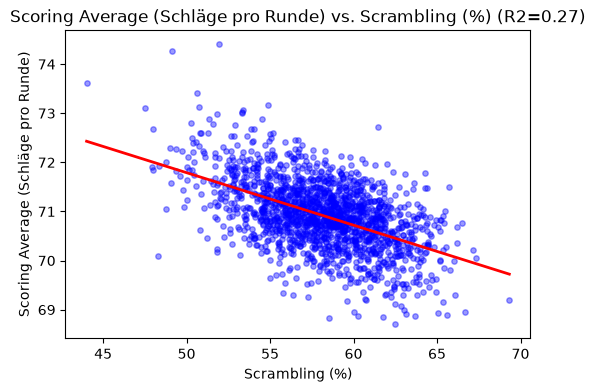

In [28]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "scoring_avg") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["scoring_avg"], alpha=0.4, s=15, color="blue")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="red", linewidth=2)
plt.xlabel("Scrambling (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title(f"Scoring Average (Schläge pro Runde) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

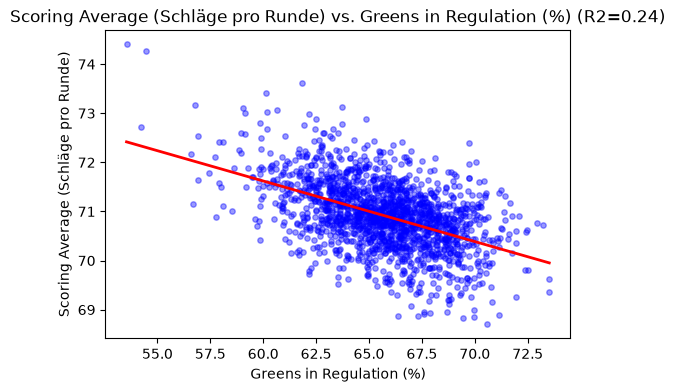

In [29]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "scoring_avg") & (ergebnis_tabelle["praediktor"] == "gir_pct")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["scoring_avg"], alpha=0.4, s=15, color="blue")

x_linie = np.linspace(df["gir_pct"].min(), df["gir_pct"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="red", linewidth=2)
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Scoring Average (Schläge pro Runde)")
plt.title(f"Scoring Average (Schläge pro Runde) vs. Greens in Regulation (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

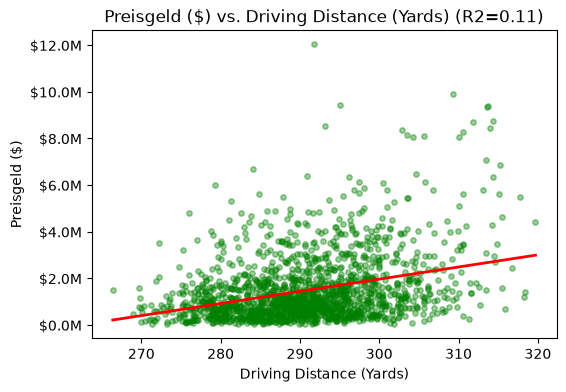

In [30]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "money") & (ergebnis_tabelle["praediktor"] == "distance")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["distance"], df["money"], alpha=0.4, s=15, color="green")

x_linie = np.linspace(df["distance"].min(), df["distance"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="red", linewidth=2)
geld_achse(plt.gca().yaxis)
plt.xlabel("Driving Distance (Yards)")
plt.ylabel("Preisgeld ($)")
plt.title(f"Preisgeld ($) vs. Driving Distance (Yards) (R2={zeile['r_quadrat']:.2f})")
plt.show()

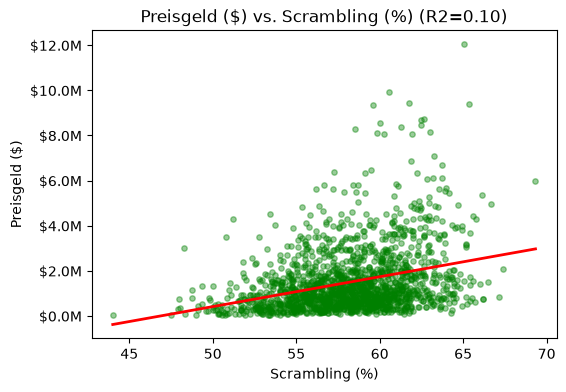

In [31]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "money") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["money"], alpha=0.4, s=15, color="green")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="red", linewidth=2)
geld_achse(plt.gca().yaxis)
plt.xlabel("Scrambling (%)")
plt.ylabel("Preisgeld ($)")
plt.title(f"Preisgeld ($) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

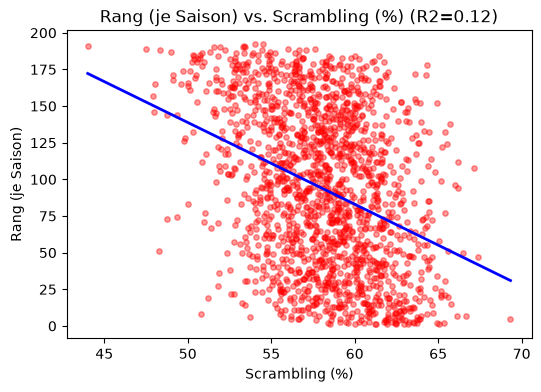

In [32]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "rank") & (ergebnis_tabelle["praediktor"] == "scrambling")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["scrambling"], df["rank"], alpha=0.4, s=15, color="red")

x_linie = np.linspace(df["scrambling"].min(), df["scrambling"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="blue", linewidth=2)
plt.xlabel("Scrambling (%)")
plt.ylabel("Rang (je Saison)")
plt.title(f"Rang (je Saison) vs. Scrambling (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

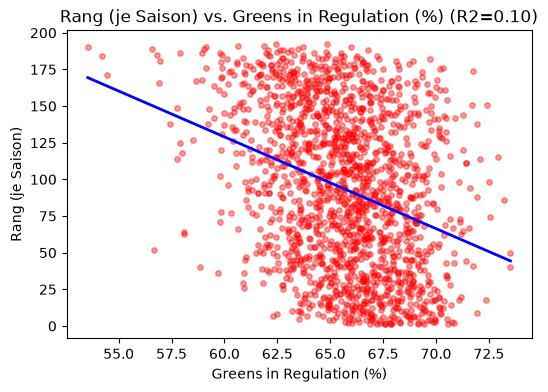

In [33]:
zeile = ergebnis_tabelle[(ergebnis_tabelle["ziel"] == "rank") & (ergebnis_tabelle["praediktor"] == "gir_pct")].iloc[0]

plt.figure(figsize=(6, 4))
plt.scatter(df["gir_pct"], df["rank"], alpha=0.4, s=15, color="red")

x_linie = np.linspace(df["gir_pct"].min(), df["gir_pct"].max(), 100)
y_linie = zeile["intercept"] + zeile["slope"] * x_linie
plt.plot(x_linie, y_linie, color="blue", linewidth=2)
plt.xlabel("Greens in Regulation (%)")
plt.ylabel("Rang (je Saison)")
plt.title(f"Rang (je Saison) vs. Greens in Regulation (%) (R2={zeile['r_quadrat']:.2f})")
plt.show()

## 5. Vergleich der Treiber

Um zu sehen welcher Prädiktor jeweils am stärksten ins Gewicht fällt, haben wir in diesem Abschnitt nochmal alle 5 Prädiktoren in einem Balkendiagramm dargestellt.

In [34]:
treiber_tabelle = ergebnis_tabelle.pivot(index="praediktor", columns="ziel", values="r_quadrat")
treiber_tabelle = treiber_tabelle[["scoring_avg", "money", "rank"]]
treiber_tabelle.loc[["distance", "accuracy", "gir_pct", "putts", "scrambling"]]

ziel,scoring_avg,money,rank
praediktor,,,
distance,0.074654,0.108435,0.064684
accuracy,0.028906,0.000264,0.007944
gir_pct,0.235254,0.098452,0.101753
putts,0.069190,0.066478,0.069088
scrambling,0.268383,0.100983,0.123222


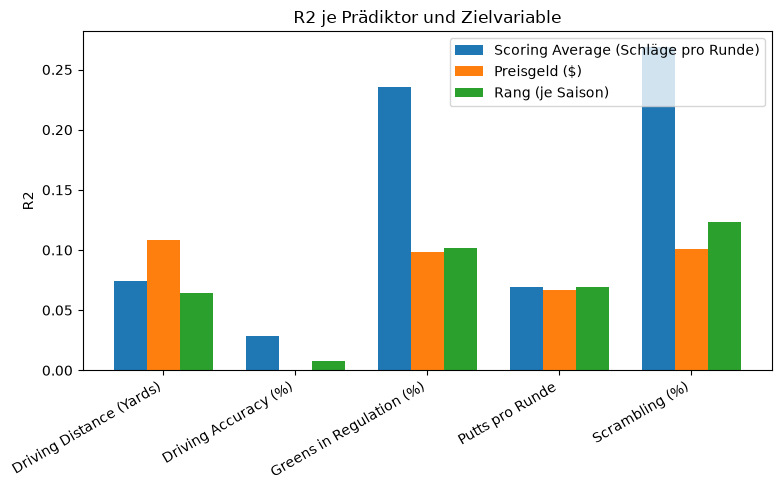

In [35]:
ziel_labels_liste = ["Scoring Average (Schläge pro Runde)", "Preisgeld ($)", "Rang (je Saison)"]
praed_labels_liste = ["Driving Distance (Yards)", "Driving Accuracy (%)", "Greens in Regulation (%)", "Putts pro Runde", "Scrambling (%)"]

x = np.arange(len(praediktoren))
breite = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, ziel in enumerate(ziel_variablen):
    werte = [treiber_tabelle.loc[p, ziel] for p in praediktoren]
    ax.bar(x + i * breite, werte, breite, label=ziel_labels_liste[i])

ax.set_xticks(x + breite)
ax.set_xticklabels(praed_labels_liste, rotation=30, ha="right")
ax.set_ylabel("R2")
ax.set_title("R2 je Prädiktor und Zielvariable")
ax.legend()
fig.tight_layout()
plt.show()

Scrambling und GIR fallen hier bspw. auch optisch sehr auf, was im Spielkontext Sinn ergibt und zu erwarten war.

In [36]:
staerkste_treiber = ergebnis_tabelle.loc[ergebnis_tabelle.groupby("ziel")["r_quadrat"].idxmax()]
staerkste_treiber[["ziel", "praediktor", "r_quadrat"]]

,ziel,praediktor,r_quadrat
5,money,distance,0.108435
14,rank,scrambling,0.123222
4,scoring_avg,scrambling,0.268383


## 6. Diskussion, Limitationen & Fazit

Bei der Interpretation ist aus unserer Sicht folgendes zu beachten:

- Der Rang wurde selbst aus den FedExCup-Punkten abgeleitet und ist eine ordinale Größe. Dies kann bei der Regression zu Problemen führen, da die Abstände nicht zwingend gleich groß sind.

- Preisgelder werden durch die Top-Verdiener stark nach oben getrieben und ziehen dadurch das Modell in ihre Richtung.

- Alle Ergebnisse hier sind Korrelationen, keine Kausalaussagen. Insgesamt bessere
Spieler schneiden oft in mehreren Bereichen gleichzeitig gut ab, ohne das sie einander verursachen.

- Die von uns gewählte Regressions-Methode beachtet nicht, ob die Prädiktoren untereinander korrelieren. Was die Korrelationsmatrix jedoch gezeigt hat.

## Fazit

Die 15 Regressionen zeigen, dass unsere Annahme bezüglich der Auswirkung, des Scramblings, größtenteils richtig war.
In allen 3 Erfolgsgrößen (Scoring Average, rank, money) ist es ein starker Prädiktor. Nur beim Preisgeld wird es von Driving Distance, jedoch relativ knapp, geschlagen.
Erfolg wie wir ihn definiert haben, hängt also nicht nur von der, wie intuitiv zu erwarten, reinen Schlaglänge ab, sondern vor allem vom Umgang mit schwierigen Spielsituationen,
wie z.B. verpassten Grüns.
